# Transformer Decoder

## Code

In [1]:
import torch
import torch.nn as nn

import models.deep_learning.architectures as mynn


## Testing

In [2]:
# input parameters
N = 3
M = 4
batch_size = 2
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
dtype = torch.float32

# Decoder Layer parameters
d_model = 4
nhead = 2
dim_feedforward = 64
dropout = 0.2
layer_norm_eps = 1e-5
batch_first = True
norm_first = True
bias = True

tgt_mask = torch.rand((N, N), device=device, dtype=dtype)
tgt_mask[tgt_mask < 0.5] = float("-inf")
tgt_mask[tgt_mask >= 0.5] = 0.0

memory_mask = torch.rand((N, M), device=device, dtype=dtype)
memory_mask[memory_mask < 0.5] = float("-inf")
memory_mask[memory_mask >= 0.5] = 0.0


## Transformer decoder parameters
num_layers = 5
#  It helps only when norm_first is True,
norm = None  # nn.LayerNorm(d_model).to(device=device,dtype=dtype)

In [3]:
torch.manual_seed(0)
x = torch.randn(batch_size, N, d_model, device=device, dtype=dtype)
memory = torch.randn(batch_size, M, d_model, device=device, dtype=dtype)

In [4]:
init_seed = 42  # avoide weights initialization randomness effects
train_seed = 24  # avoid dropout randomness effects

In [5]:
torch.manual_seed(init_seed)
tf_decl = mynn.TransformerDecoderLayer(
    d_model,
    nhead,
    dim_feedforward=dim_feedforward,
    dropout=dropout,
    activation_cls=nn.GELU,
    layer_norm_eps=layer_norm_eps,
    norm_first=norm_first,
    bias=bias,
    device=device,
    dtype=dtype,
)

torch.manual_seed(init_seed)
nn_tf_decl = nn.TransformerDecoderLayer(
    d_model,
    nhead,
    dim_feedforward=dim_feedforward,
    dropout=dropout,
    activation="gelu",
    layer_norm_eps=layer_norm_eps,
    batch_first=batch_first,
    norm_first=norm_first,
    bias=bias,
    device=device,
    dtype=dtype,
)

tf_dec = mynn.TransformerDecoder(tf_decl, num_layers, norm=norm)
nn_tf_dec = nn.TransformerDecoder(
    nn_tf_decl,
    num_layers,
    norm=norm,
)

tf_dec.load_weights_from_torch_decoder(nn_tf_dec)

### Evaluation

In [6]:
tf_dec.eval()
tf_dec(x, memory, tgt_mask=tgt_mask, memory_mask=memory_mask)

tensor([[[-0.7312, -1.1288,  0.6845, -2.5712],
         [ 1.6673,  1.5544,  0.4275,  1.9403],
         [ 1.1364,  1.1569, -1.3320,  1.1963]],

        [[ 0.1630,  2.9069, -0.8750,  4.1585],
         [ 0.8959,  1.6988, -0.0787,  3.1985],
         [ 2.7913,  2.2299,  2.4847,  2.8145]]], device='mps:0',
       grad_fn=<AddBackward0>)

In [7]:
nn_tf_dec.eval()
nn_tf_dec(x, memory, tgt_mask=tgt_mask, memory_mask=memory_mask)

tensor([[[-0.7312, -1.1288,  0.6845, -2.5712],
         [ 1.6673,  1.5544,  0.4275,  1.9403],
         [ 1.1364,  1.1569, -1.3320,  1.1963]],

        [[ 0.1630,  2.9069, -0.8750,  4.1585],
         [ 0.8959,  1.6988, -0.0787,  3.1985],
         [ 2.7913,  2.2299,  2.4847,  2.8145]]], device='mps:0',
       grad_fn=<AddBackward0>)

### Training

In [8]:
mse = torch.nn.MSELoss()

In [9]:
torch.manual_seed(train_seed)
nn_tf_dec.train()
out = nn_tf_dec(x, memory)
print(out)
loss = mse(out, x)
loss.backward()
optimizer = torch.optim.SGD(nn_tf_dec.parameters(), lr=1e-3)
optimizer.step()
nn_tf_dec(x, memory)


tensor([[[ 0.0831, -1.0748,  1.1178, -1.3246],
         [ 0.7610,  1.0347,  0.4498,  1.1008],
         [ 0.0937,  0.9695,  0.9439,  1.1212]],

        [[-0.5338,  2.8519, -1.1166,  2.3343],
         [ 0.2728,  1.0747, -0.3270,  1.5421],
         [ 2.0798,  1.5716,  0.8372, -0.2262]]], device='mps:0',
       grad_fn=<AddBackward0>)


tensor([[[-1.1053, -0.5690,  0.4414, -1.3384],
         [ 0.4897,  0.6562,  1.1868,  0.6527],
         [ 0.4249, -0.0604,  1.5427, -0.8686]],

        [[-0.4918,  0.7960,  0.1244,  2.1720],
         [ 0.2392,  0.8240, -1.2797, -0.0614],
         [ 2.5211,  1.9466,  1.7205,  1.1239]]], device='mps:0',
       grad_fn=<AddBackward0>)

In [10]:
torch.manual_seed(train_seed)
tf_dec.train()
out = tf_dec(x, memory)
print(out)
loss = mse(out, x)
loss.backward()
optimizer = torch.optim.SGD(tf_dec.parameters(), lr=1e-3)
optimizer.step()
tf_dec(x, memory)

tensor([[[ 0.0831, -1.0748,  1.1178, -1.3246],
         [ 0.7610,  1.0347,  0.4498,  1.1008],
         [ 0.0937,  0.9695,  0.9439,  1.1212]],

        [[-0.5338,  2.8519, -1.1166,  2.3343],
         [ 0.2728,  1.0747, -0.3270,  1.5421],
         [ 2.0798,  1.5716,  0.8372, -0.2262]]], device='mps:0',
       grad_fn=<AddBackward0>)


tensor([[[-1.1061, -0.5693,  0.4405, -1.3389],
         [ 0.4889,  0.6558,  1.1873,  0.6523],
         [ 0.4245, -0.0606,  1.5422, -0.8691]],

        [[-0.4922,  0.7960,  0.1241,  2.1714],
         [ 0.2393,  0.8244, -1.2798, -0.0612],
         [ 2.5210,  1.9469,  1.7193,  1.1245]]], device='mps:0',
       grad_fn=<AddBackward0>)

## Training Task: Sequence Reversal

Reverse a source sequence of length $N$ drawn from vocabulary $V$.

**Why this tests the decoder specifically:**

* **Cross-attention is required** — the decoder must look at memory (the embedded source) to know
  what the reversed tokens are. A model that ignores cross-attention cannot solve this.
* **Causal self-attention is tested** — teacher forcing with an upper-triangular $-\infty$ mask
  prevents the decoder from peeking at future targets during training.
* **Autoregressive decoding** — after training we verify the decoder generates correctly one token
  at a time (no teacher forcing), which tests the full inference loop.

Architecture (decoder-only, encoder replaced by a learned embedding):

$$\text{memory} = \text{Embed}_{\text{src}}(\mathbf{s}) \qquad
  \hat{\mathbf{t}} = \text{head}(\text{Decoder}(\text{Embed}_{\text{tgt}}(\mathbf{t}_{\text{in}}),\;\text{memory}))$$

In [11]:
import math
import matplotlib.pyplot as plt

# ── Hyper-parameters ──────────────────────────────────────────────────────────
V = 8  # token vocabulary  {0 … 7}
SEQ_LEN = 5  # source / target length
D = 32  # d_model (larger than the unit-test above to give capacity)
NHEAD = 4
NLAYERS = 2
FF = 128
BOS = V  # BOS index (= V, one beyond the regular vocab)

# ── Data ─────────────────────────────────────────────────────────────────────
# src:     (B, SEQ_LEN) – random integer sequences
# tgt_in:  (B, SEQ_LEN) – BOS + reversed src (drop last token)  ← decoder input
# tgt_out: (B, SEQ_LEN) – reversed src                          ← prediction target


def make_batch(batch_size: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    src = torch.randint(0, V, (batch_size, SEQ_LEN), device=device)
    rev = src.flip(1)
    bos_col = torch.full((batch_size, 1), BOS, device=device)
    tgt_in = torch.cat([bos_col, rev[:, :-1]], dim=1)  # BOS + first SEQ_LEN-1 of rev
    tgt_out = rev  # full reversed src
    return src, tgt_in, tgt_out


# ── Model ─────────────────────────────────────────────────────────────────────
# Positional embeddings are required: without them the cross-attention is
# permutation-equivariant over memory and cannot learn "attend to the last
# source position first."  Token + position embeddings are summed, following
# the standard transformer word-encoding pattern.

torch.manual_seed(0)
src_tok_emb = nn.Embedding(V, D, device=device)  # source token embeddings
src_pos_emb = nn.Embedding(SEQ_LEN, D, device=device)  # source positional embeddings
tgt_tok_emb = nn.Embedding(V + 1, D, device=device)  # +1 for BOS
tgt_pos_emb = nn.Embedding(SEQ_LEN, D, device=device)  # target positional embeddings

src_pos = torch.arange(SEQ_LEN, device=device).unsqueeze(0)  # (1, SEQ_LEN)

dec_layer = mynn.TransformerDecoderLayer(
    D,
    NHEAD,
    dim_feedforward=FF,
    dropout=0.0,
    activation_cls=nn.GELU,
    norm_first=True,
    device=device,
    dtype=dtype,
)

nn_dec_layer = nn.TransformerDecoderLayer(
    D,
    NHEAD,
    dim_feedforward=FF,
    dropout=0.0,
    activation="gelu",
    batch_first=True,
    norm_first=True,
    device=device,
    dtype=dtype,
)

rev_decoder = mynn.TransformerDecoder(
    dec_layer, NLAYERS, norm=nn.LayerNorm(D, device=device, dtype=dtype)
)

## Compare with PyTorch's built-in decoder, to validate our implementation and
nn_rev_decoder = nn.TransformerDecoder(
    nn_dec_layer, NLAYERS, norm=nn.LayerNorm(D, device=device, dtype=dtype)
)
rev_decoder.load_weights_from_torch_decoder(nn_rev_decoder)


rev_head = nn.Linear(D, V, device=device, dtype=dtype)

all_params = (
    list(src_tok_emb.parameters())
    + list(src_pos_emb.parameters())
    + list(tgt_tok_emb.parameters())
    + list(tgt_pos_emb.parameters())
    + list(rev_decoder.parameters())
    + list(rev_head.parameters())
)
optimizer = torch.optim.Adam(all_params, lr=3e-4)
criterion = nn.CrossEntropyLoss()

# Causal mask: prevents each decoder position from attending to future positions.
tgt_causal_mask = torch.triu(
    torch.full((SEQ_LEN, SEQ_LEN), float("-inf"), device=device), diagonal=1
)

print(f"Parameters: {sum(p.numel() for p in all_params):,}")
print(f"Random-baseline cross-entropy ≈ log({V}) = {math.log(V):.3f}")

Parameters: 35,176
Random-baseline cross-entropy ≈ log(8) = 2.079


epoch  50  loss=1.8014
epoch 100  loss=0.8884
epoch 150  loss=0.2568


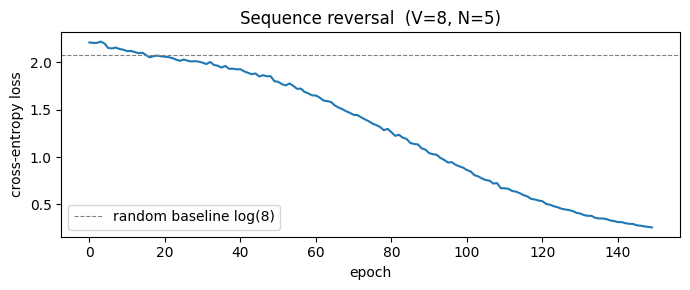

In [12]:
EPOCHS = 150
BATCH_SIZE = 256

train_losses = []
for epoch in range(1, EPOCHS + 1):
    src_tok_emb.train()
    src_pos_emb.train()
    tgt_tok_emb.train()
    tgt_pos_emb.train()
    rev_decoder.train()
    rev_head.train()

    src, tgt_in, tgt_out = make_batch(BATCH_SIZE)

    memory = src_tok_emb(src) + src_pos_emb(src_pos)  # (B, SEQ_LEN, D)
    tgt_e = tgt_tok_emb(tgt_in) + tgt_pos_emb(src_pos)  # (B, SEQ_LEN, D)

    out = rev_decoder(tgt_e, memory, tgt_mask=tgt_causal_mask)  # (B, SEQ_LEN, D)
    logits = rev_head(out)  # (B, SEQ_LEN, V)
    loss = criterion(logits.reshape(-1, V), tgt_out.reshape(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    if epoch % 50 == 0:
        print(f"epoch {epoch:3d}  loss={loss.item():.4f}")

plt.figure(figsize=(7, 3))
plt.plot(train_losses)
plt.axhline(
    y=math.log(V),
    color="gray",
    linestyle="--",
    linewidth=0.8,
    label=f"random baseline log({V})",
)
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title(f"Sequence reversal  (V={V}, N={SEQ_LEN})")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
@torch.no_grad()
def greedy_decode(src_seq: torch.Tensor) -> list[int]:
    """Autoregressive decoding — no teacher forcing, one token at a time."""
    src_tok_emb.eval()
    src_pos_emb.eval()
    tgt_tok_emb.eval()
    tgt_pos_emb.eval()
    rev_decoder.eval()
    rev_head.eval()

    mem = src_tok_emb(src_seq.unsqueeze(0)) + src_pos_emb(src_pos)  # (1, SEQ_LEN, D)
    tgt = torch.tensor([[BOS]], device=device)

    for step in range(SEQ_LEN):
        step_pos = torch.arange(step + 1, device=device).unsqueeze(0)
        tgt_e = tgt_tok_emb(tgt) + tgt_pos_emb(step_pos)  # (1, step+1, D)
        mask = torch.triu(
            torch.full((step + 1, step + 1), float("-inf"), device=device), diagonal=1
        )
        out = rev_decoder(tgt_e, mem, tgt_mask=mask)
        next_tok = rev_head(out[:, -1]).argmax(-1, keepdim=True)
        tgt = torch.cat([tgt, next_tok], dim=1)

    return tgt[0, 1:].tolist()  # strip BOS


# ── Evaluate on fresh examples (no training data overlap) ────────────────────
N_TEST = 20
correct = 0
print("src              expected         predicted        ok")
print("─" * 60)
for _ in range(N_TEST):
    src_seq = torch.randint(0, V, (SEQ_LEN,), device=device)
    expected = src_seq.flip(0).tolist()
    pred = greedy_decode(src_seq)
    ok = pred == expected
    correct += int(ok)
    print(f"{src_seq.tolist()}  →  {expected}  →  {pred}  {'✓' if ok else '✗'}")

print(f"\nAccuracy: {correct}/{N_TEST} = {correct / N_TEST:.0%}")

src              expected         predicted        ok
────────────────────────────────────────────────────────────
[0, 4, 2, 4, 3]  →  [3, 4, 2, 4, 0]  →  [3, 4, 2, 4, 0]  ✓
[7, 4, 6, 5, 4]  →  [4, 5, 6, 4, 7]  →  [4, 5, 6, 4, 7]  ✓
[6, 1, 6, 6, 7]  →  [7, 6, 6, 1, 6]  →  [7, 6, 6, 1, 6]  ✓
[5, 5, 6, 1, 6]  →  [6, 1, 6, 5, 5]  →  [6, 1, 6, 5, 5]  ✓
[4, 4, 4, 2, 0]  →  [0, 2, 4, 4, 4]  →  [0, 2, 4, 4, 4]  ✓
[6, 5, 2, 7, 7]  →  [7, 7, 2, 5, 6]  →  [7, 7, 2, 5, 6]  ✓
[6, 6, 2, 5, 1]  →  [1, 5, 2, 6, 6]  →  [1, 5, 2, 6, 6]  ✓
[5, 6, 5, 2, 1]  →  [1, 2, 5, 6, 5]  →  [1, 2, 5, 6, 5]  ✓
[0, 0, 4, 4, 4]  →  [4, 4, 4, 0, 0]  →  [4, 4, 4, 0, 0]  ✓
[5, 1, 2, 2, 3]  →  [3, 2, 2, 1, 5]  →  [3, 2, 2, 1, 5]  ✓
[7, 5, 7, 1, 2]  →  [2, 1, 7, 5, 7]  →  [2, 1, 7, 5, 7]  ✓
[3, 6, 1, 2, 3]  →  [3, 2, 1, 6, 3]  →  [3, 2, 1, 6, 3]  ✓
[2, 3, 2, 1, 1]  →  [1, 1, 2, 3, 2]  →  [1, 1, 2, 3, 2]  ✓
[2, 7, 5, 3, 7]  →  [7, 3, 5, 7, 2]  →  [7, 3, 5, 7, 2]  ✓
[1, 6, 4, 2, 3]  →  [3, 2, 4, 6, 1]  →  [3, 2, 4, 6, 1]  ✓
